In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sms
import pandas as pd

ModuleNotFoundError: No module named 'numpy'

In [ ]:
df=pd.read_excel('/content/wheat.xlsx',index_col='Date',parse_dates=True)
# You can explicitly set the frequency of your time series using df.index.freq = 'MS' (for monthly data) or 'D', 'Y', etc.
df.index.freq = 'MS'
print('Shape of data',df.shape)
df

Shape of data (127, 15)


,Bihar,Delhi,Gujarat,Haryana,Karnataka,Kerala,Madhya Pradesh,Maharashtra,Odisha,Punjab,Rajasthan,Tamil Nadu,Uttar Pradesh,West Bengal,All India Average
Date,,,,,,,,,,,,,,,
2014-01-01,1787.10,1652.25,1820.73,1577.03,2635.53,2487.10,1519.93,2218.21,1800.00,1543.75,1708.71,2611.32,1593.00,1700.00,1965.41
2014-02-01,1765.71,1637.50,1825.00,1565.94,2616.07,2551.85,1525.41,2275.60,1802.40,1550.00,1726.25,2672.88,1631.71,1700.00,1964.95
2014-03-01,1818.75,1660.50,1712.50,1587.25,2626.09,2570.00,1538.54,2272.92,1803.00,1503.00,1677.88,2678.57,1635.00,1700.00,1953.01
2014-04-01,1746.00,1690.00,1678.13,1615.74,2595.24,2633.33,1463.75,2156.07,1803.00,1505.41,1689.74,2656.12,1485.08,1700.00,1917.15
2014-05-01,1704.41,1753.33,1732.50,1600.14,2592.86,2588.33,1478.26,2128.61,1803.00,1500.00,1666.91,2667.92,1450.16,1700.00,1891.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,2482.04,2600.00,3223.33,2479.09,3923.47,4014.65,2541.40,3281.16,3317.93,2289.76,2598.30,4020.20,2443.68,2655.81,2987.42
2024-04-01,2442.98,2600.00,3170.79,2491.04,3911.05,4007.31,2535.88,3236.68,3306.23,2282.63,2604.36,4013.27,2394.10,2649.54,2963.55
2024-05-01,2405.49,2600.00,3193.92,2476.40,3909.03,3973.22,2562.22,3270.40,3273.34,2299.94,2625.05,4019.82,2365.43,2638.79,2958.12


In [ ]:
df = df[['Gujarat']]

df

,Gujarat
Date,
2014-01-01,1820.73
2014-02-01,1825.00
2014-03-01,1712.50
2014-04-01,1678.13
2014-05-01,1732.50
...,...
2024-03-01,3223.33
2024-04-01,3170.79
2024-05-01,3193.92


In [ ]:
df.isnull().sum()

,0
Gujarat,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 127 entries, 2014-01-01 to 2024-07-01
Freq: MS
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Gujarat  127 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB


<Axes: xlabel='Date'>

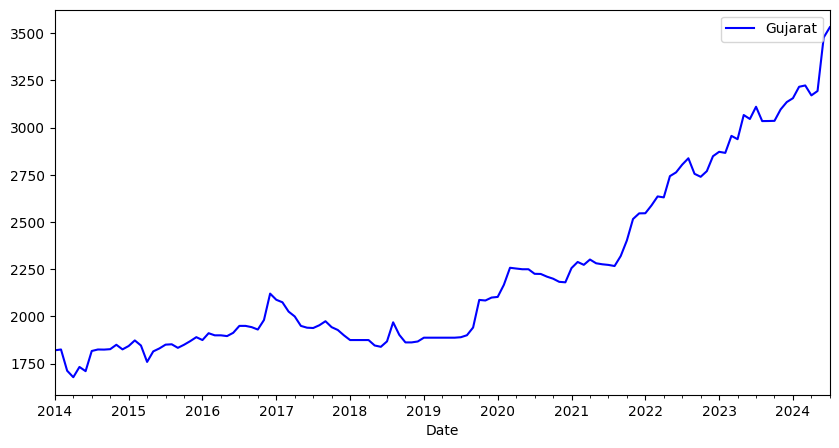

In [ ]:
df.plot(figsize=(10, 5), color='blue')

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [ ]:
adfuller_test(df)

ADF Test Statistic : 2.5181471716583435
p-value : 0.9990554695568462
#Lags Used : 0
Number of Observations Used : 126
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [ ]:
# 1 month
df['Gujarat Price 1 Difference'] = df['Gujarat'] - df['Gujarat'].shift(1)
adfuller_test(df['Gujarat Price 1 Difference'].dropna())

ADF Test Statistic : -10.06464805912058
p-value : 1.3059439733272579e-17
#Lags Used : 0
Number of Observations Used : 125
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<ipython-input-30-47d0643d2ed8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gujarat Price 1 Difference'] = df['Gujarat'] - df['Gujarat'].shift(1)


In [ ]:
# 2 months
df['Gujarat Price 2 Difference'] = df['Gujarat'] - df['Gujarat'].shift(2)
adfuller_test(df['Gujarat Price 2 Difference'].dropna())

ADF Test Statistic : -4.624833318087146
p-value : 0.00011621931510086636
#Lags Used : 2
Number of Observations Used : 122
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<ipython-input-31-7c3666b20e57>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gujarat Price 2 Difference'] = df['Gujarat'] - df['Gujarat'].shift(2)


In [ ]:
# 3 months
df['Gujarat Price 3 Difference'] = df['Gujarat'] - df['Gujarat'].shift(3)
adfuller_test(df['Gujarat Price 3 Difference'].dropna())

ADF Test Statistic : -2.3449153820368185
p-value : 0.15789061695556839
#Lags Used : 7
Number of Observations Used : 116
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


<ipython-input-32-2c766b126b9b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gujarat Price 3 Difference'] = df['Gujarat'] - df['Gujarat'].shift(3)


In [ ]:
# 6 months
df['Gujarat Price 6 Difference']=df['Gujarat']-df['Gujarat'].shift(6)
adfuller_test(df['Gujarat Price 6 Difference'].dropna())

ADF Test Statistic : -1.0974260576657155
p-value : 0.7160972713089233
#Lags Used : 12
Number of Observations Used : 108
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


<ipython-input-33-b8c2d826e48e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gujarat Price 6 Difference']=df['Gujarat']-df['Gujarat'].shift(6)


In [ ]:
# 12 months
df['Gujarat Price 12 Difference']=df['Gujarat']-df['Gujarat'].shift(12)
adfuller_test(df['Gujarat Price 12 Difference'].dropna())

ADF Test Statistic : -0.9605807760232251
p-value : 0.7673687866100797
#Lags Used : 12
Number of Observations Used : 102
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


<ipython-input-34-38dcf94682ba>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gujarat Price 12 Difference']=df['Gujarat']-df['Gujarat'].shift(12)


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

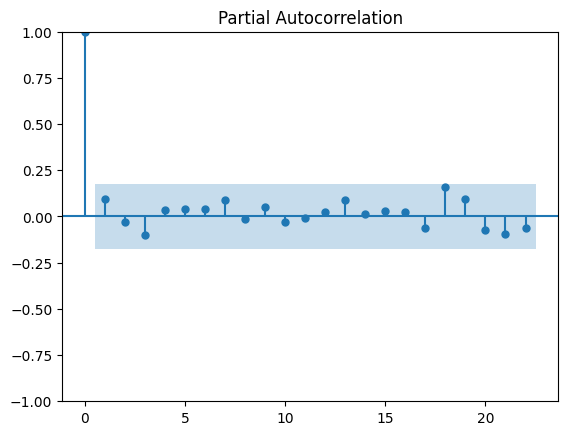

In [ ]:
pacf = plot_pacf(df["Gujarat Price 1 Difference"].dropna())

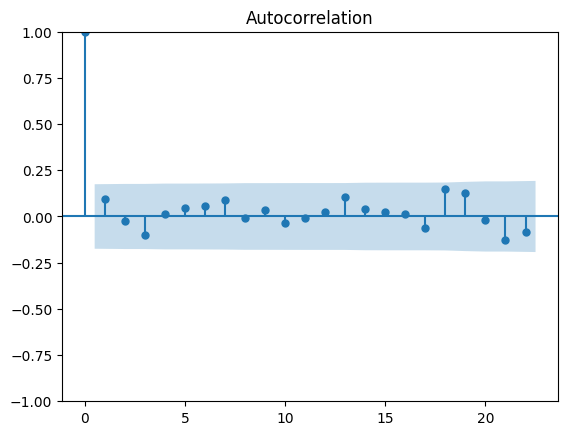

In [ ]:
acf = plot_acf(df["Gujarat Price 1 Difference"].dropna())

In [ ]:
train = df.loc[:'2022-07-01', 'Gujarat']
test = df.loc['2022-07-01':, 'Gujarat']

In [ ]:
test

,Gujarat
Date,
2022-07-01,2804.11
2022-08-01,2837.70
2022-09-01,2755.37
2022-10-01,2739.53
2022-11-01,2769.51
2022-12-01,2848.61
2023-01-01,2871.90
2023-02-01,2866.23
2023-03-01,2956.32


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


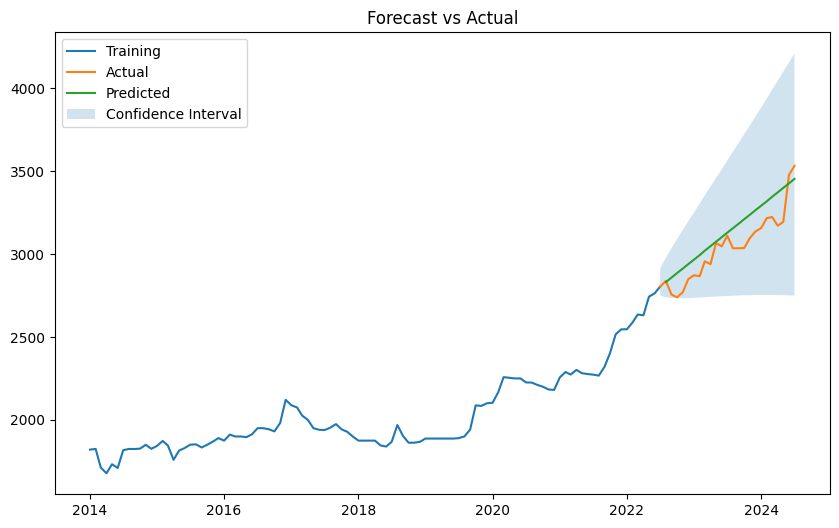

MAE: 107.07884959524199


In [ ]:
# If you did a train-test split:
n_periods = len(test)  # forecast the same number of steps as the test set
forecast, conf_int = auto_arima_model.predict(n_periods=n_periods, return_conf_int=True)

# Convert forecast to a Pandas Series with a date index matching 'test'
forecast_index = test.index
forecast_series = pd.Series(forecast, index=forecast_index)

# Plot predictions vs. actual
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual')
plt.plot(forecast_series.index, forecast_series, label='Predicted')
plt.fill_between(
    forecast_series.index,
    conf_int[:, 0],
    conf_int[:, 1],
    alpha=0.2,
    label='Confidence Interval'
)
plt.title('Forecast vs Actual')
plt.legend()
plt.show()

# Calculate an error metric, e.g. Mean Absolute Error
mae = np.mean(np.abs(test - forecast_series))
print(f'MAE: {mae}')


In [ ]:
predict_df=pd.read_excel('/content/Prediction.xlsx',index_col='Date',parse_dates=True)


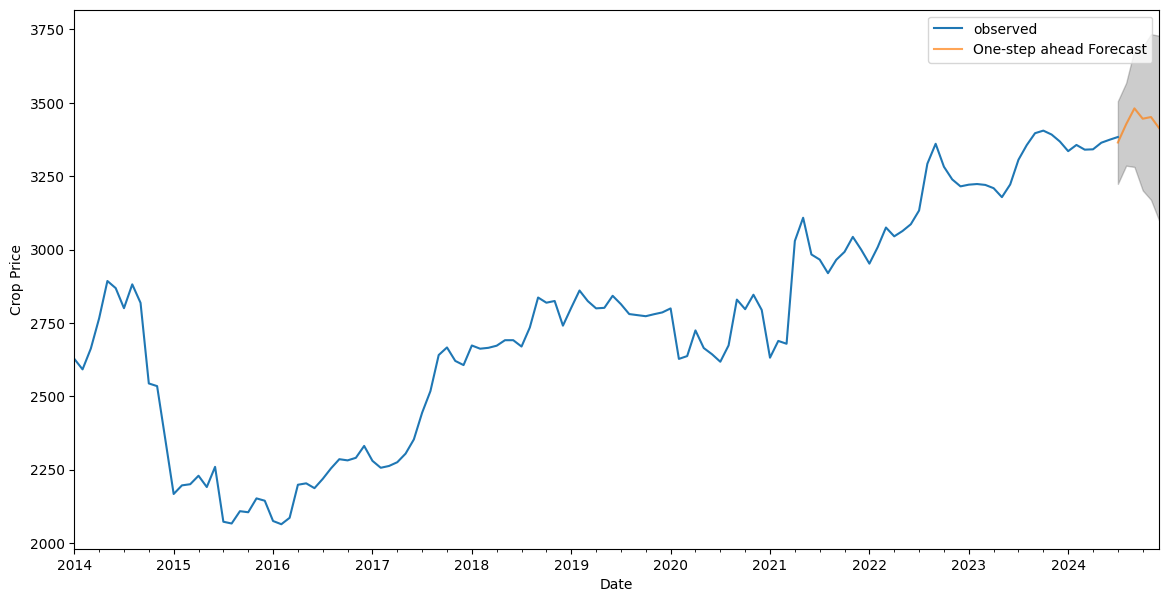

In [ ]:
pred = results.get_prediction(start=pd.to_datetime('2024-07-01'), end=pd.to_datetime('2024-12-01'), dynamic=False)
pred_ci = pred.conf_int()
ax = df['Bihar'].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Crop Price')
plt.legend()
plt.show()
